# Introdução e Carregamento dos Dados

O dataset Palmer Penguins contém informações sobre pinguins de diferentes espécies, com variáveis numéricas (medidas físicas) e categóricas (espécie, ilha, sexo).

## Objetivo
Realizar análise exploratória dos dados, incluindo:
- Tratamento de valores ausentes
- Análise de variáveis categóricas
- Análise de variáveis numéricas

A análise utiliza conceitos estatísticos como média, mediana, variância e quartis para entender o comportamento dos dados.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('penguins.csv', sep=';')

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


# PARTE 1: Valores Ausentes (NaN)

## O que são valores ausentes?
São dados que não foram preenchidos.

#### Por que tratar?
Eles podem distorcer cálculos estatísticos como média e variância.

#### Estratégia utilizada:
- Variáveis numéricas → mediana
- Variáveis categóricas → moda

#### Mediana:
Valor central dos dados ordenados. Não sofre influência de valores extremos (outliers)

#### Moda:
Valor mais frequente. Ideal para variáveis categóricas





### Identificação dos valores ausentes

Os valores ausentes (NaN) foram identificados utilizando funções da biblioteca Pandas:

- `isna()` → identifica valores ausentes
- `sum()` → contabiliza quantos existem por coluna

Também foi calculada a porcentagem de valores ausentes para avaliar o impacto no dataset.

---

#### Técnica utilizada: IMPUTAÇÃO DE DADOS

Sim, foi utilizada uma técnica estatística chamada:

**Imputação de Dados (Data Imputation)**

Essa técnica consiste em substituir valores ausentes por valores estimados, ao invés de remover os dados.

---

### Estratégia aplicada

#### Variáveis Numéricas → MEDIANA

A mediana é o valor central dos dados ordenados.

Motivo da escolha: Não sofre influência de outliers e tem uma representação  melhor o centro dos dados em distribuições assimétricas

---

#### Variáveis Categóricas → MODA

A moda é o valor mais frequente.  
Motivo da escolha: Mantém a categoria mais representativa e é ideal para variáveis qualitativas

---

### Por que não usar remoção?

A remoção de dados (`dropna()`) não foi utilizada pois: Reduz o tamanho da amostra e pode causar perda de informação importante

---

#### Conclusão

Foi aplicada a técnica de imputação:
- Numéricas → mediana
- Categóricas → moda

Essa abordagem mantém o tamanho do dataset e garante *maior* consistência estatística.

In [13]:
# Quantidade de valores nulos
nulos_qtd = df.isna().sum()

# Porcentagem
nulos_pct = (df.isna().sum() / len(df)) * 100

print("Quantidade de nulos:")
print(nulos_qtd)

print("\nPorcentagem de nulos:")
print(nulos_pct)

# Definição das colunas
cols_num = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
cols_cat = ['species', 'island', 'sex']

# Preenchimento com mediana (numéricas)
for col in cols_num:
    df[col] = df[col].fillna(df[col].median())

# Preenchimento com moda (categóricas)
for col in cols_cat:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nValores ausentes tratados.")

Quantidade de nulos:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Porcentagem de nulos:
species              0.000000
island               0.000000
bill_length_mm       0.581395
bill_depth_mm        0.581395
flipper_length_mm    0.581395
body_mass_g          0.581395
sex                  3.197674
dtype: float64

Valores ausentes tratados.


# PARTE 2: Análise de Variáveis Categóricas

**O que foi pedido no Roteiro:** Para cada variável categórica (`species`, `island`, `sex`), calcular frequências absoluta e relativa, identificar a moda e gerar gráficos.

**Contexto:** O objetivo é identificar padrões como espécie mais comum e distribuição de sexo.

## Objetivo
Entender a distribuição dos dados categóricos.

## Medidas utilizadas

### Frequência absoluta
Quantidade de vezes que cada categoria aparece

### Frequência relativa
Proporção (percentual)

### Moda
Valor mais frequente

## Para que?
- Identificar padrões
- Ver qual classe é dominante
- Analisar equilíbrio dos dados


Análise da variável: species
Moda: Adelie

Frequência Absoluta:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Frequência Relativa:
species
Adelie       0.441860
Gentoo       0.360465
Chinstrap    0.197674
Name: proportion, dtype: float64


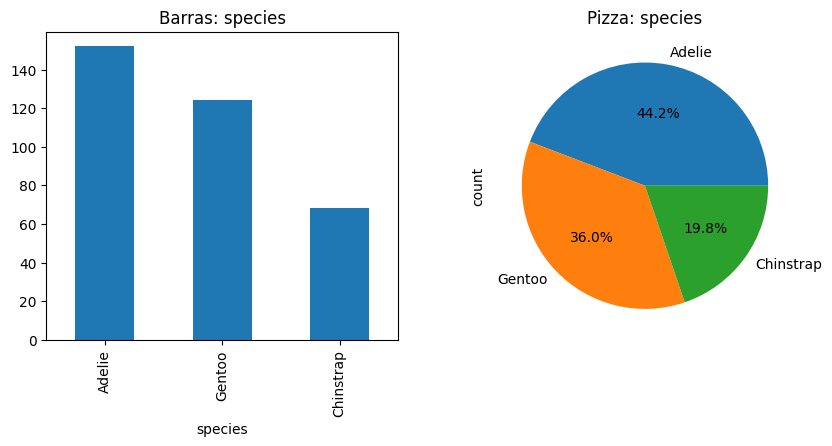


Análise da variável: island
Moda: Biscoe

Frequência Absoluta:
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

Frequência Relativa:
island
Biscoe       0.488372
Dream        0.360465
Torgersen    0.151163
Name: proportion, dtype: float64


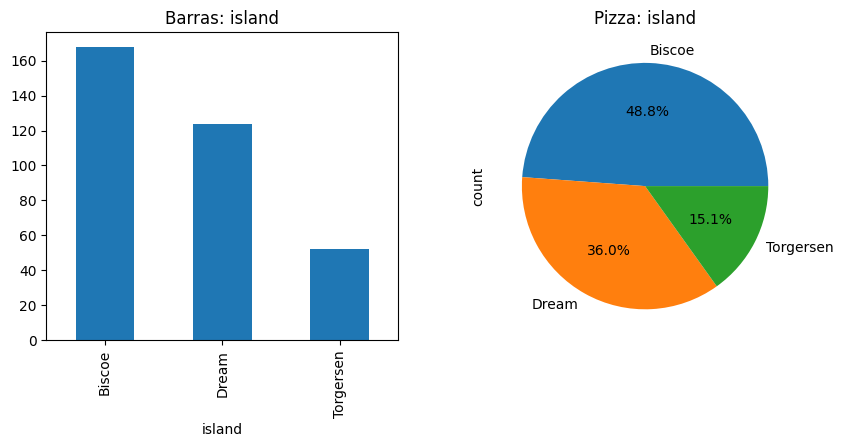


Análise da variável: sex
Moda: MALE

Frequência Absoluta:
sex
MALE      179
FEMALE    165
Name: count, dtype: int64

Frequência Relativa:
sex
MALE      0.520349
FEMALE    0.479651
Name: proportion, dtype: float64


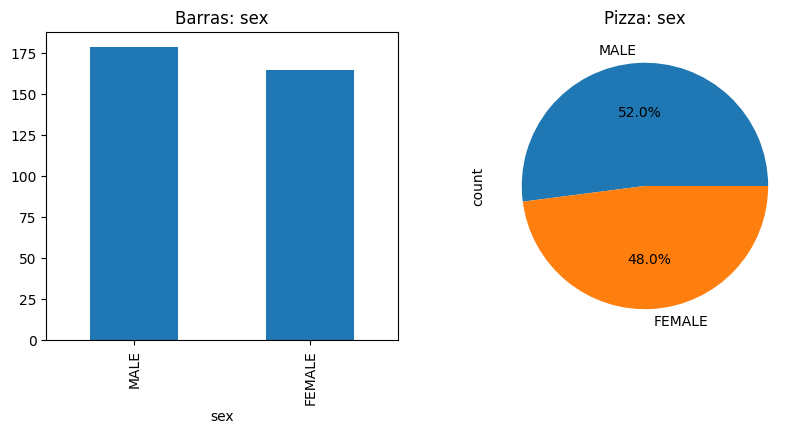

In [14]:
for col in cols_cat:
    print(f"\nAnálise da variável: {col}")
    
    # Frequência absoluta
    freq_abs = df[col].value_counts()
    
    # Frequência relativa
    freq_rel = df[col].value_counts(normalize=True)
    
    # Moda
    moda = df[col].mode()[0]
    
    print(f"Moda: {moda}")
    print("\nFrequência Absoluta:")
    print(freq_abs)
    
    print("\nFrequência Relativa:")
    print(freq_rel)
    
    # Gráficos
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    freq_abs.plot(kind='bar', title=f'Barras: {col}')
    
    plt.subplot(1, 2, 2)
    freq_abs.plot(kind='pie', autopct='%1.1f%%', title=f'Pizza: {col}')
    
    plt.show()

# PARTE 3: Análise de Variáveis Numéricas

**O que foi pedido no Roteiro:** Calcular medidas estatísticas (média, mediana, variância, desvio padrão, quartis, etc.) e gerar histogramas e boxplots.

# PARTE 3: Variáveis Numéricas

## Medidas estatísticas

### Média
Soma dos valores dividido pela quantidade

### Mediana
Valor central dos dados ordenados

### Variância
Mede o quanto os dados se afastam da média

### Desvio padrão
Raiz da variância → dispersão dos dados

### Amplitude
Diferença entre maior e menor valor

### Coeficiente de variação
Indica dispersão relativa (%)

### Quartis
Dividem os dados em 4 partes:
- Q1 → 25%
- Q2 → mediana
- Q3 → 75%

### IIQ (Intervalo interquartil)
Q3 - Q1 → mede dispersão central

### Outliers
Valores muito distantes:
- abaixo de Q1 - 1.5×IIQ
- acima de Q3 + 1.5×IIQ


Análise da variável: bill_length_mm
Média: 43.93
Mediana: 44.45
Moda: 41.10
Variância: 29.63
Desvio padrão: 5.44
Amplitude: 27.50
Coeficiente de variação: 12.39%
Q1: 39.27 | Q2: 44.45 | Q3: 48.50
IIQ: 9.23
Outliers: 0


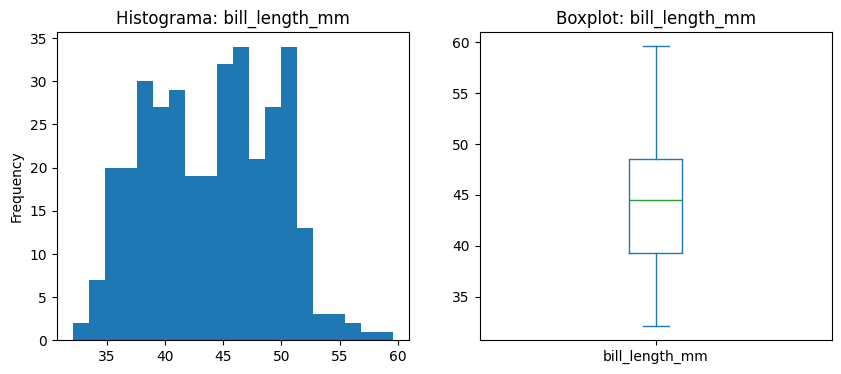


Análise da variável: bill_depth_mm
Média: 17.15
Mediana: 17.30
Moda: 17.00
Variância: 3.88
Desvio padrão: 1.97
Amplitude: 8.40
Coeficiente de variação: 11.48%
Q1: 15.60 | Q2: 17.30 | Q3: 18.70
IIQ: 3.10
Outliers: 0


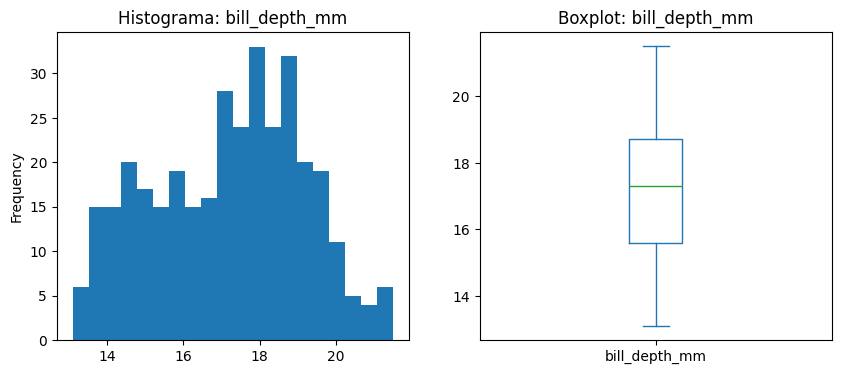


Análise da variável: flipper_length_mm
Média: 200.89
Mediana: 197.00
Moda: 190.00
Variância: 196.67
Desvio padrão: 14.02
Amplitude: 59.00
Coeficiente de variação: 6.98%
Q1: 190.00 | Q2: 197.00 | Q3: 213.00
IIQ: 23.00
Outliers: 0


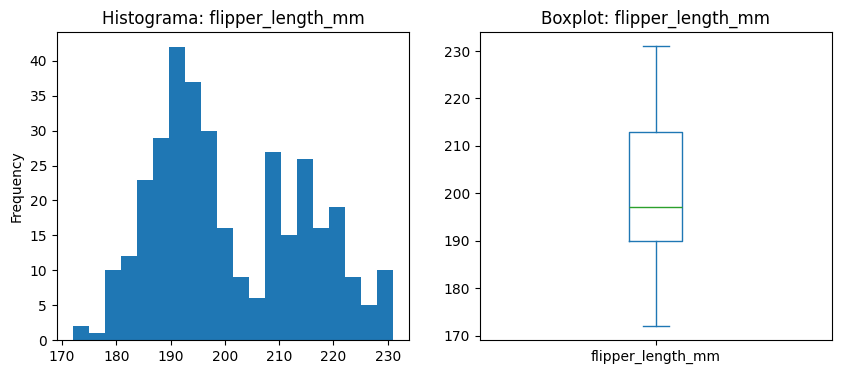


Análise da variável: body_mass_g
Média: 4200.87
Mediana: 4050.00
Moda: 3800.00
Variância: 639514.54
Desvio padrão: 799.70
Amplitude: 3600.00
Coeficiente de variação: 19.04%
Q1: 3550.00 | Q2: 4050.00 | Q3: 4750.00
IIQ: 1200.00
Outliers: 0


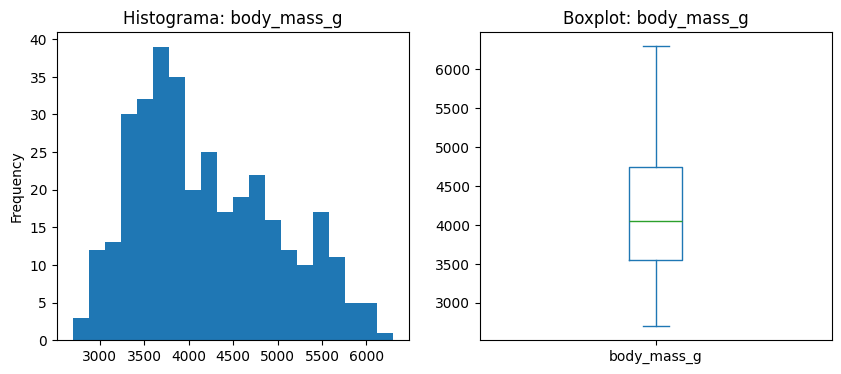

In [15]:
for col in cols_num:
    print(f"\nAnálise da variável: {col}")
    
    # MÉDIA
    media = df[col].mean()
    
    # MEDIANA
    mediana = df[col].median()
    
    # MODA
    moda = df[col].mode()[0]
    
    # VARIÂNCIA
    variancia = df[col].var()
    
    # DESVIO PADRÃO
    desvio = df[col].std()
    
    # AMPLITUDE
    amplitude = df[col].max() - df[col].min()
    
    # COEFICIENTE DE VARIAÇÃO
    coef_var = (desvio / media) * 100
    
    # QUARTIS
    q1 = df[col].quantile(0.25)
    q2 = df[col].quantile(0.5)
    q3 = df[col].quantile(0.75)
    
    # IIQ
    iiq = q3 - q1
    
    # LIMITES DE OUTLIERS
    lim_inf = q1 - 1.5 * iiq
    lim_sup = q3 + 1.5 * iiq
    
    outliers = df[(df[col] < lim_inf) | (df[col] > lim_sup)]
    
    # PRINTS
    print(f"Média: {media:.2f}")
    print(f"Mediana: {mediana:.2f}")
    print(f"Moda: {moda:.2f}")
    print(f"Variância: {variancia:.2f}")
    print(f"Desvio padrão: {desvio:.2f}")
    print(f"Amplitude: {amplitude:.2f}")
    print(f"Coeficiente de variação: {coef_var:.2f}%")
    print(f"Q1: {q1:.2f} | Q2: {q2:.2f} | Q3: {q3:.2f}")
    print(f"IIQ: {iiq:.2f}")
    print(f"Outliers: {len(outliers)}")
    
    # GRÁFICOS
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    df[col].plot(kind='hist', bins=20, title=f'Histograma: {col}')
    
    plt.subplot(1, 2, 2)
    df[col].plot(kind='box', title=f'Boxplot: {col}')
    
    plt.show()

# Conclusão

- A análise permitiu identificar padrões nas variáveis categóricas, como a espécie mais frequente.
- As variáveis numéricas apresentaram diferentes níveis de dispersão.
- Algumas variáveis possuem outliers, indicando valores extremos.
- O coeficiente de variação ajudou a identificar qual variável é mais instável.

#### Conclusão Geral
Os dados apresentam comportamento consistente, com algumas variações naturais entre espécies, o que é esperado em dados biológicos.